# **Movie Review Sentiment Analysis**

# **Problem Statement**

The objective of this project is to build a Machine Learning model that automatically analyzes movie reviews and predicts the sentiment expressed in the review. The model will classify each review as either Positive or Negative based on the textual content.

# **Target Analysis**

Sentiment

- The target variable represents the sentiment associated with each movie review.

Typical classes:
- Positive
- Negative


# **Text Feature**

Review
- The main input feature is the textual movie review written by a user or viewer.

# **Business Objective**

The objective is to analyze movie reviews and identify positive or negative audience sentiment, helping movie companies and streaming platforms understand viewer feedback and improve their content and audience engagement.


In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# download required NLTK resources (run once)
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# **Importing Data**

In [2]:
df = pd.read_csv("/content/IMDB Dataset.csv", engine = "python")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# **EDA**

In [3]:
# dataset shape
df.shape

(50000, 2)

In [4]:
# display first few records
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# display tail few records
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [6]:
# datatypes of dataset
df.dtypes

,0
review,object
sentiment,object


In [7]:
# text feature
text_column = "review"

In [8]:
# target variable
target_column = "sentiment"

In [9]:
print("Text Column:", text_column)
print("Target Column:", target_column)

Text Column: review
Target Column: sentiment


In [10]:
# basic information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [11]:
# check for missing values
df.isnull().sum()

,0
review,0
sentiment,0


**Observation**
- The dataset contains no missing values.

In [12]:
# check duplicate records
df.duplicated().sum()

np.int64(418)

In [13]:
# drop duplicates
df = df.drop_duplicates()

In [14]:
df.shape

(49582, 2)

**Target Variable Analysis**

In [15]:
# class distribution
class_distribution = df['sentiment'].value_counts()

print("Class Distribution:")
print(class_distribution)

Class Distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


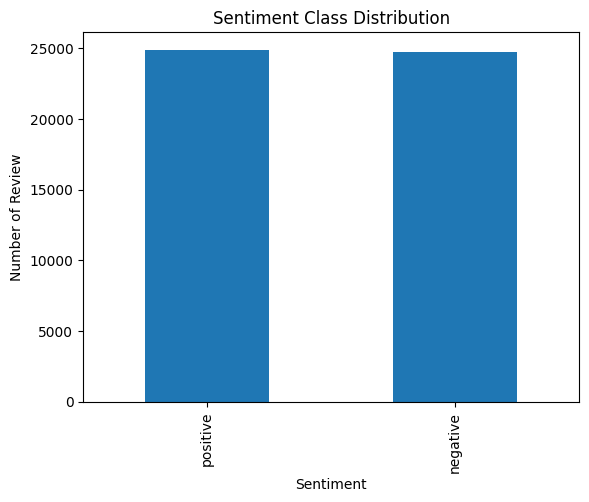

In [16]:
# visualize class distribution

class_distribution.plot(kind = "bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Review")
plt.show()

In [17]:
# percentage of each class
class_percentage = df['sentiment'].value_counts(normalize= True) * 100

print("Percentage of Each Class:")
print(class_percentage.round(2))

Percentage of Each Class:
sentiment
positive    50.19
negative    49.81
Name: proportion, dtype: float64


**Observation**

The dataset is well balanced balanced, with 50.19% positive reviews and 49.81% negative reviews. Therefore, there is no significant class imbalance between the two sentiment categories.

**Text Analysis**

In [18]:
# char count
df['char_count'] = df['review'].apply(len)
df['char_count'].head()

,char_count
0,1761
1,998
2,926
3,748
4,1317


In [19]:
# word count
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
df['word_count'].head()

,word_count
0,307
1,162
2,166
3,138
4,230


In [20]:
# sentence count
import re

df['sentence_count'] = df['review'].apply(
    lambda x: len(re.findall(r'[.!?]+', x))
)
df['sentence_count'].head()

,sentence_count
0,17
1,7
2,7
3,10
4,15


In [21]:
# average word length
df['avg_word_length'] = df['review'].apply(
    lambda x: sum(len(word) for word in x.split()) / len(x.split())
)
df['avg_word_length'].head()

,avg_word_length
0,4.739414
1,5.166667
2,4.584337
3,4.427536
4,4.730435


In [22]:
# vocabulary size

# combine all reviews
all_reviews = " ".join(df['review']).lower()

# extract words
words = re.findall(r"\b[a-z]+\b", all_reviews)

# vocabulary size
vocab_size = len(set(words))

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 98751


In [23]:
df[['char_count',
    'word_count',
    'sentence_count',
    'avg_word_length']].describe()

,char_count,word_count,sentence_count,avg_word_length
count,49582.000000,49582.000000,49582.000000,49582.000000
mean,1310.568230,231.350167,13.154552,4.640984
std,990.762238,171.542020,9.374651,0.340527
min,32.000000,4.000000,0.000000,1.239865
25%,699.000000,126.000000,7.000000,4.418247
50%,971.000000,173.000000,11.000000,4.627119
75%,1592.000000,281.000000,16.000000,4.847605
max,13704.000000,2470.000000,282.000000,12.290909


**Univariate Analysis**

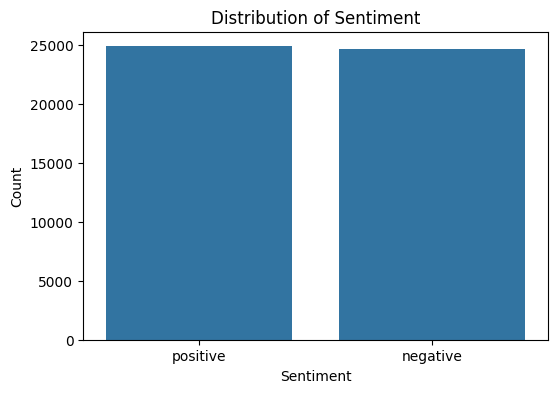

In [24]:
# count plot
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)

plt.title("Distribution of Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

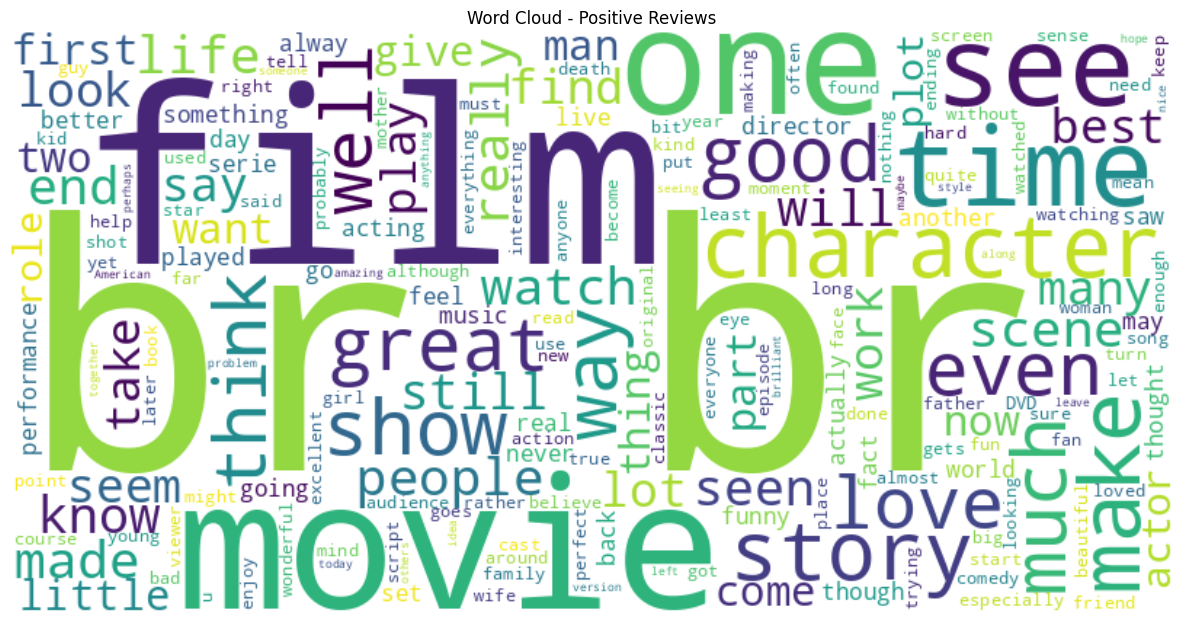

In [25]:
# word cloud for positive reviews

from wordcloud import WordCloud

postive_text = " ".join(df[df['sentiment'] == 'positive']['review'])

word_cloud = WordCloud(
    width = 800,
    height = 400,
    background_color = "white"
).generate(postive_text)

plt.figure(figsize= (15,8))
plt.imshow(word_cloud, interpolation= "bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()


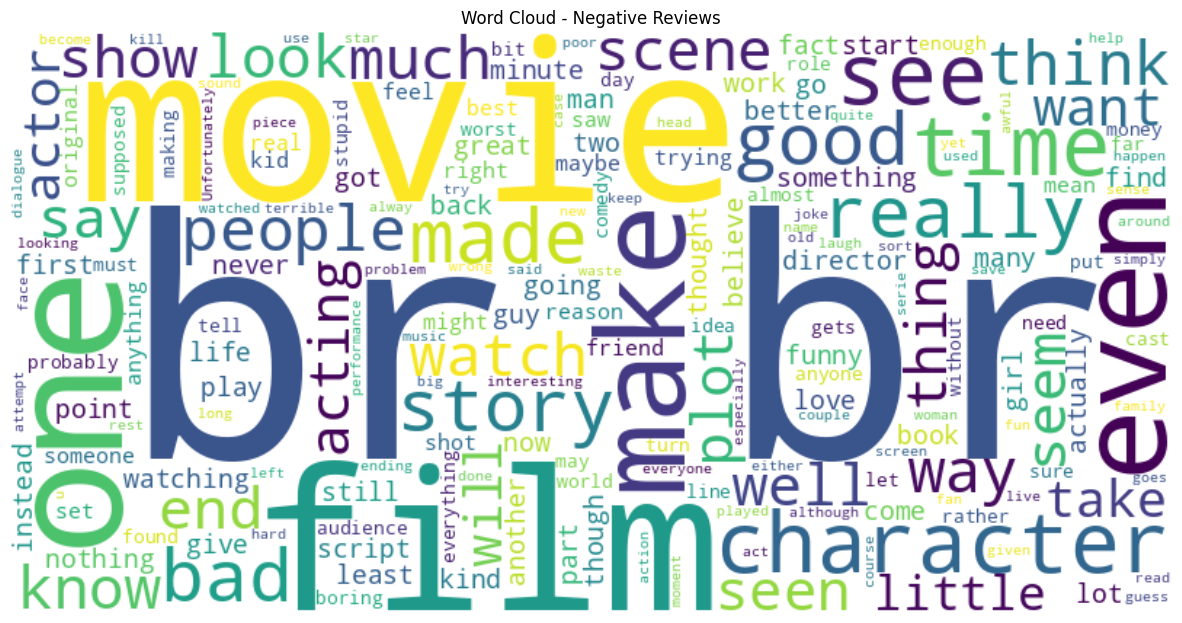

In [26]:
# word cloud for negative reviews

from wordcloud import WordCloud

negative_text = " ".join(df[df['sentiment'] == 'negative']['review'])

word_cloud = WordCloud(
    width = 800,
    height = 400,
    background_color = "white"
).generate(negative_text)

plt.figure(figsize= (15,8))
plt.imshow(word_cloud, interpolation= "bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

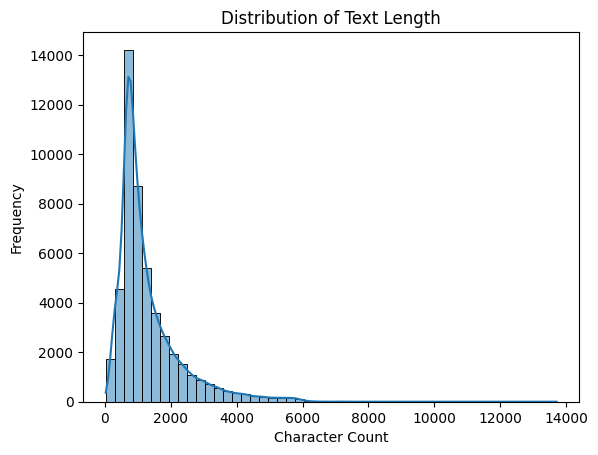

In [27]:
# Histogram of text lengths

sns.histplot(df['char_count'], bins = 50, kde = True)
plt.title("Distribution of Text Length")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

In [28]:
df['char_count'].skew()

np.float64(2.1832844779788)

The distribution of text length is positively (right) skewed.

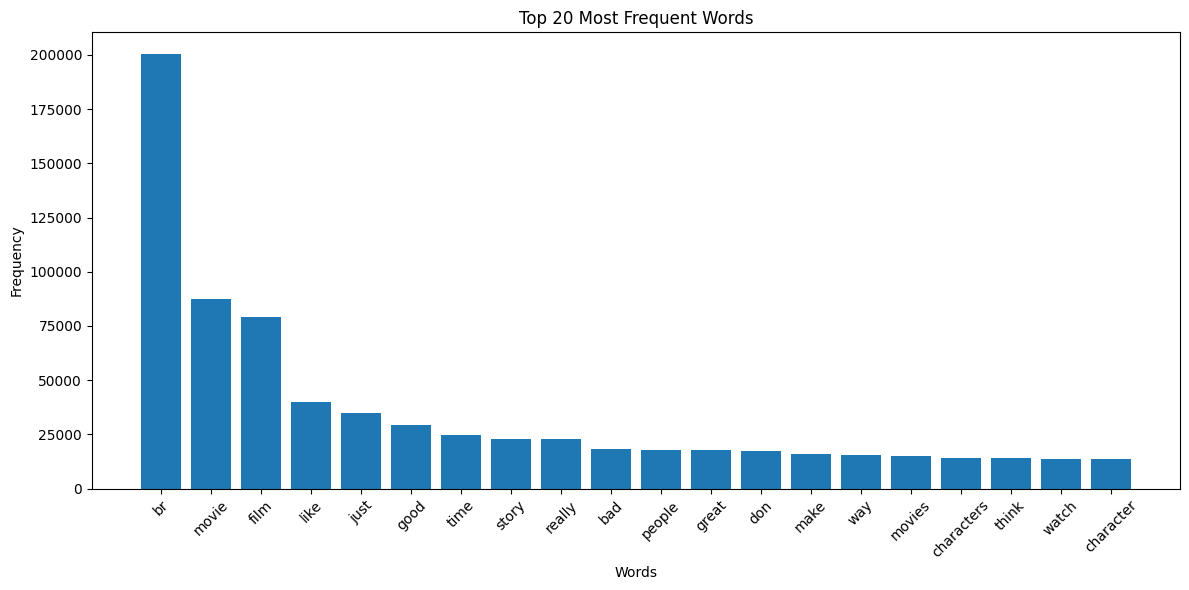

In [29]:
# word frequency plot

from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer
cv = CountVectorizer(stop_words='english')

# Fit and transform the review column
X = cv.fit_transform(df['review'])

# Calculate word frequencies
word_freq = X.sum(axis=0).A1

# Get feature names
words = cv.get_feature_names_out()

# Create DataFrame
freq_df = pd.DataFrame({
    "Word": words,
    "Frequency": word_freq
})

# Top 20 frequent words
top20 = freq_df.sort_values(by="Frequency", ascending=False).head(20)

# Plot
plt.figure(figsize=(12,6))
plt.bar(top20["Word"], top20["Frequency"])
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation**

- The dataset is well balanced, with nearly equal proportions of positive and negative reviews.
- The review length distribution is right-skewed, indicating that most reviews are short to medium in length, while only a small number of reviews are considerably longer.

**Insights**

- The balanced sentiment classes help reduce the risk of model bias toward either positive or negative sentiment.
- The right-skewed review length suggests that most users tend to provide concise feedback, while only a few users write longer or detailed reviews.

**Recommendations**

- Apply text preprocessing techniques such as stop-word removal, punctuation cleaning, and lemmatization to improve text quality.
- Use TF-IDF vectorization instead of raw word frequencies to give greater importance to informative and distinctive words.
- Retain text length features, such as character count and word count, as additional engineered features for further analysis and potentially improving model performance.

**Bivariate Analysis**

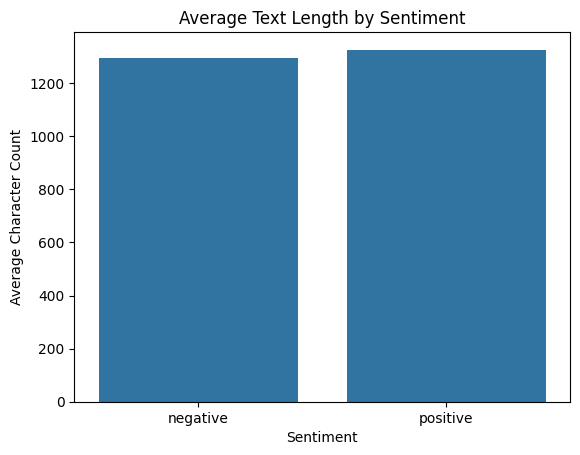

In [30]:
# Average Text Length by Class

avg_length = df.groupby('sentiment')['char_count'].mean().reset_index()

# plot
sns.barplot(data = avg_length, x = 'sentiment', y = 'char_count')
plt.title("Average Text Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Character Count")
plt.show()

Text(0.5, 1.0, 'Top 20 Words in Positive Reviews')

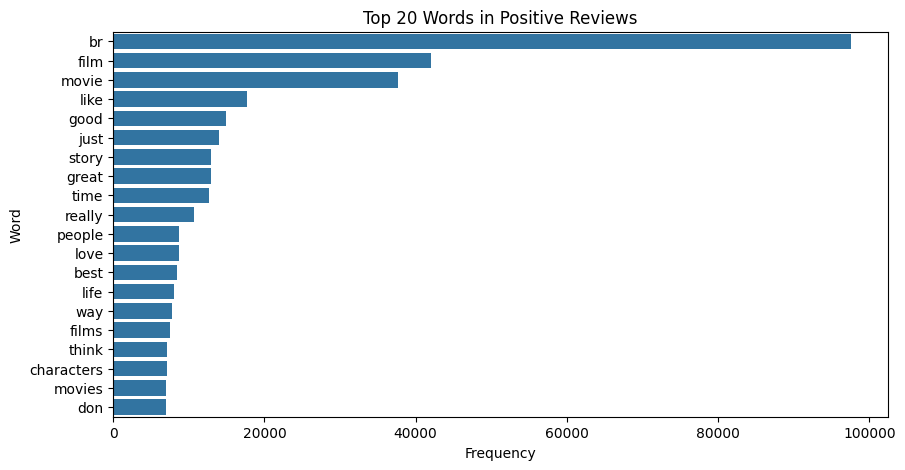

In [31]:
# Top Words in Each Sentiment Class

# top 20 words in positive reviews
positive_reviews = df[df['sentiment'] == 'positive']['review']

cv = CountVectorizer(stop_words= "english", max_features = 20)

X = cv.fit_transform(positive_reviews)

freq = X.sum(axis = 0).A1

positive_words = pd.DataFrame({
    "Word": cv.get_feature_names_out(),
    "Frequency": freq
}).sort_values(by = "Frequency", ascending = False)

# plot
plt.figure(figsize= (10,5))
sns.barplot(data = positive_words, x = 'Frequency', y = 'Word')
plt.title("Top 20 Words in Positive Reviews")

Text(0.5, 1.0, 'Top 20 Words in Negative Reviews')

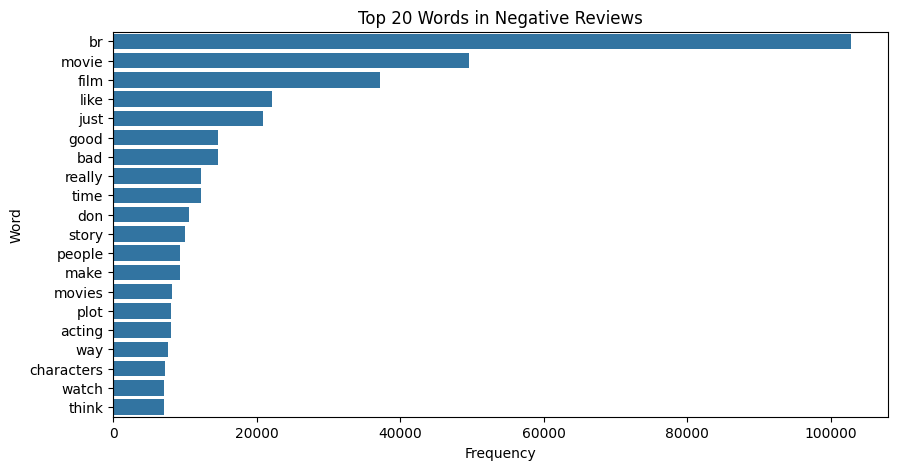

In [32]:

# top 20 words in negative reviews
negative_reviews = df[df['sentiment'] == 'negative']['review']

cv = CountVectorizer(stop_words= "english", max_features = 20)

X = cv.fit_transform(negative_reviews)

freq = X.sum(axis = 0).A1

negative_words = pd.DataFrame({
    "Word": cv.get_feature_names_out(),
    "Frequency": freq
}).sort_values(by = "Frequency", ascending = False)

# plot
plt.figure(figsize= (10,5))
sns.barplot(data = negative_words, x = 'Frequency', y = 'Word')
plt.title("Top 20 Words in Negative Reviews")

**Insight**

- Positive and negative reviews have almost the same average length, which suggests that the - words used in a review are more important for determining sentiment than the length of the review.
- Words such as “good,” “great,” “love,” “best,” and “like” are commonly used in positive reviews, showing that opinion-based words play an important role in identifying sentiment.
- The frequent appearance of “br” indicates that some HTML content is still present in the reviews and may add unnecessary noise.

**Recommendations**

- Clean the text more thoroughly by removing HTML tags, unwanted tokens such as "br", punctuation, and other unnecessary characters.
- Use TF-IDF vectorization to give more importance to words that are useful for identifying sentiment.
- Retain meaningful sentiment words during preprocessingas they can help the model better distinguish between positive and negative reviews.

**Multivariate Analysis**

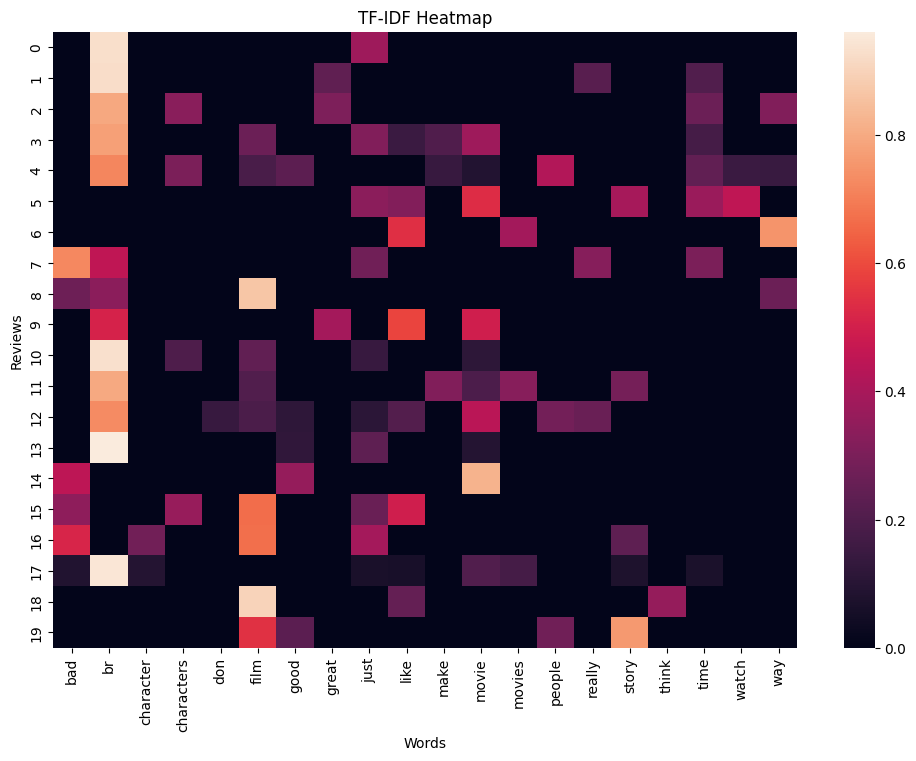

In [33]:
# TF-IDF Heatmap

from sklearn.feature_extraction.text import TfidfVectorizer

# Tf-IDf vectorizer
tfidf = TfidfVectorizer(stop_words = "english", max_features = 20)

tfidf_matrix = tfidf.fit_transform(df['review'])

# convert to dataframe
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns = tfidf.get_feature_names_out()
)

# plot
plt.figure(figsize=(12,8))
sns.heatmap(tfidf_df.head(20), cbar = True)
plt.title("TF-IDF Heatmap")
plt.xlabel("Words")
plt.ylabel("Reviews")
plt.show()

# **Feature Engineering**

In [34]:
#	Character Count
df['char_count'] = df['review'].apply(len)

In [35]:
# word count
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

In [36]:
# sentence count
df['sentence_count'] = df['review'].apply(
    lambda x: len(re.findall(r"[.!?]+",x))
)

In [37]:
df['avg_word_length'] = df['review'].apply(
    lambda x: sum(len(word) for word in x.split()) / len(x.split())
    if len(x.split()) > 0 else 0
)

In [38]:
# Number of stop words
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

df['stopword_count'] = df['review'].apply(
    lambda x: len(
        [word for word in x.lower().split()
        if word in stop_words]
    )
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
# Number of punctuation marks

df['punctuation_count'] = df['review'].apply(
    lambda x: sum(1 for char in x if char in string.punctuation)
)

In [40]:
# Number of digits
df['digit_count'] = df['review'].apply(
    lambda x: sum(char.isdigit() for char in x)
)

In [41]:
# Number of capital letters
df['capital_count'] = df['review'].apply(
    lambda x: sum(char.isupper() for char in x)
)

In [42]:
df[['char_count',
    'word_count',
    'sentence_count',
    'avg_word_length',
    'stopword_count',
    'punctuation_count',
    'digit_count',
    'capital_count']].head()

,char_count,word_count,sentence_count,avg_word_length,stopword_count,punctuation_count,digit_count,capital_count
0,1761,307,17,4.739414,133,78,1,43
1,998,162,7,5.166667,66,44,0,16
2,926,166,7,4.584337,78,40,1,23
3,748,138,10,4.427536,62,42,3,24
4,1317,230,15,4.730435,96,56,0,34


In [43]:
df.head()

,review,sentiment,char_count,word_count,sentence_count,avg_word_length,stopword_count,punctuation_count,digit_count,capital_count
0,One of the other reviewers has mentioned that ...,positive,1761,307,17,4.739414,133,78,1,43
1,A wonderful little production. <br /><br />The...,positive,998,162,7,5.166667,66,44,0,16
2,I thought this was a wonderful way to spend ti...,positive,926,166,7,4.584337,78,40,1,23
3,Basically there's a family where a little boy ...,negative,748,138,10,4.427536,62,42,3,24
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230,15,4.730435,96,56,0,34


# **Input-Output Separation**

In [44]:
# input feature (text column)
X = df['review']

# target variable
y = df['sentiment']

print("Input feature")
print(X.head())
print("\nTarget Variable")
print(y.head())

Input feature
0    One of the other reviewers has mentioned that ...
1    A wonderful little production. <br /><br />The...
2    I thought this was a wonderful way to spend ti...
3    Basically there's a family where a little boy ...
4    Petter Mattei's "Love in the Time of Money" is...
Name: review, dtype: object

Target Variable
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object


In [45]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (49582,)
Shape of y: (49582,)


# **Train-Test Split**

In [46]:
from sklearn.model_selection import train_test_split

# split the dataset into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

print("Training Set (X_train):", X_train.shape)
print("Testing Set (X_test):", X_test.shape)

print("Training Labels (y_train):", y_train.shape)
print("Testing Labels (y_test):", y_test.shape)

Training Set (X_train): (39665,)
Testing Set (X_test): (9917,)
Training Labels (y_train): (39665,)
Testing Labels (y_test): (9917,)


# **Text Preprocessing**

**Text Cleaning**

In [47]:
# Text cleaning
def clean_text(text):

  # convert to lowercase
  text = text.lower()

  # Remove HTML tags
  text = re.sub(r"<.*?>", "", text)

  # Remove URLs
  text = re.sub(r"https?://\S+", "", text)

  # Remove emojis
  emoji_pattern = re.compile("["
                             u"\U0001F600-\U0001F64F"
                               u"\U0001F300-\U0001F5FF"
                               u"\U0001F680-\U0001F6FF"
                               u"\U0001F1E0-\U0001F1FF"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)

  text = emoji_pattern.sub(r"", text)

  # remove numbers
  text = re.sub(r"\d+", "", text)

  # remove punctuation
  text = re.sub(r"[^\w\s]", "", text)

  # remove special characters
  text = re.sub(r"[^a-zA-Z\s]", "", text)

  # remove extra whitespace
  text = re.sub(r"\s+", " ", text).strip()

  return text

In [48]:
# Apply clean text to train and test data
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

In [49]:
# Original text and cleaned text
print("Original Review:\n")
print(X_train.iloc[0])

print("Cleaned Review:\n")
print(X_train_clean.iloc[0])

Original Review:

I am one of Jehovah's Witnesses and I also work in an acute care medical facility. Over the years I have seen people die from hemolytic reactions to blood transfusions, have attended numerous conferences on blood born pathogens, and have seen several patients become seriously ill from pathogens induced by transfused blood. I have also heard several Jehovah's Witnesses being told that they will die if they refuse blood and after 26 years in the field I have never actually seen it happen, leaving the question, "is it really unreasonable to refuse blood transfusions or is the community at large benefiting from the battle on this issue?" The issue for Jehovah's Witnesses is a moral one. "You must abstain from blood" is not an ambiguous statement. Thank you for this movie and allowing comments on it.
Cleaned Review:

i am one of jehovahs witnesses and i also work in an acute care medical facility over the years i have seen people die from hemolytic reactions to blood trans

In [50]:
X_train_clean.head()

,review
34797,i am one of jehovahs witnesses and i also work...
17295,amongst the standard one liner type action fil...
9424,realty television crew are assigned to cover a...
21987,the funniest scene of this movie is probably w...
10839,there have been far too few mainstream films s...


**Tokenization**

In [51]:
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [52]:
# Tokenize the cleaned text
X_train_tokens = X_train_clean.apply(word_tokenize)

# Tokenize testing data
X_test_tokens = X_test_clean.apply(word_tokenize)

In [53]:
X_train_tokens.head()

,review
34797,"[i, am, one, of, jehovahs, witnesses, and, i, ..."
17295,"[amongst, the, standard, one, liner, type, act..."
9424,"[realty, television, crew, are, assigned, to, ..."
21987,"[the, funniest, scene, of, this, movie, is, pr..."
10839,"[there, have, been, far, too, few, mainstream,..."


**Stopword Removal**

In [54]:
# Remove stopwords from training data
X_train_stopwords = X_train_tokens.apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

# Remove stopwords from testing data
X_test_stopwords = X_test_tokens.apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

**Lemmatization**

In [55]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

# initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# lemmatize training data
X_train_lemma = X_train_stopwords.apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)
# lemmatize texting data
X_test_lemma = X_test_stopwords.apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [56]:
print("Before Lemmatization:\n")
print(X_train_stopwords.iloc[0])

print("\nAfter Lemmatization:\n")
print(X_train_lemma.iloc[0])

Before Lemmatization:

['one', 'jehovahs', 'witnesses', 'also', 'work', 'acute', 'care', 'medical', 'facility', 'years', 'seen', 'people', 'die', 'hemolytic', 'reactions', 'blood', 'transfusions', 'attended', 'numerous', 'conferences', 'blood', 'born', 'pathogens', 'seen', 'several', 'patients', 'become', 'seriously', 'ill', 'pathogens', 'induced', 'transfused', 'blood', 'also', 'heard', 'several', 'jehovahs', 'witnesses', 'told', 'die', 'refuse', 'blood', 'years', 'field', 'never', 'actually', 'seen', 'happen', 'leaving', 'question', 'really', 'unreasonable', 'refuse', 'blood', 'transfusions', 'community', 'large', 'benefiting', 'battle', 'issue', 'issue', 'jehovahs', 'witnesses', 'moral', 'one', 'must', 'abstain', 'blood', 'ambiguous', 'statement', 'thank', 'movie', 'allowing', 'comments']

After Lemmatization:

['one', 'jehovah', 'witness', 'also', 'work', 'acute', 'care', 'medical', 'facility', 'year', 'seen', 'people', 'die', 'hemolytic', 'reaction', 'blood', 'transfusion', 'atten

In [57]:
# convert tokens back to text
X_train_text = X_train_lemma.apply(lambda tokens: " ".join(tokens))
X_test_text = X_test_lemma.apply(lambda tokens: " ".join(tokens))

In [58]:
X_train_text.head()

,review
34797,one jehovah witness also work acute care medic...
17295,amongst standard one liner type action film ac...
9424,realty television crew assigned cover small to...
21987,funniest scene movie probably saviour get meda...
10839,far mainstream film set postcolonial africa on...


# **Text Vectorization**

**Count Vectorizer (Bag of Words)**

In [59]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features= 5000)

# fit on training data and transform
X_train_cv = cv.fit_transform(X_train_text)

# transform testing data
X_test_cv = cv.transform(X_test_text)

In [60]:
print("Training Shape:", X_train_cv.shape)
print("Testing Shape:", X_test_cv.shape)

Training Shape: (39665, 5000)
Testing Shape: (9917, 5000)


**TF-IDF Vectorizer**

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

# fit and transform data
X_train_tfidf = tfidf.fit_transform(X_train_text)

# transform the test data
X_test_tfidf = tfidf.transform(X_test_text)

In [62]:
print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (39665, 5000)
Testing Shape: (9917, 5000)


In [63]:
print(tfidf.get_feature_names_out()[:20])

['aaron' 'abandoned' 'abc' 'ability' 'able' 'abrupt' 'absence' 'absent'
 'absolute' 'absolutely' 'absurd' 'absurdity' 'abuse' 'abused' 'abusive'
 'abysmal' 'academy' 'accent' 'accept' 'acceptable']


The dataset is balanced, so handling imbalanced data is not required.

# **Model Building**

In [64]:
# Multi Nomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# create model
nb = MultinomialNB()

# train the model
nb.fit(X_train_tfidf, y_train)

# predict
y_pred_nb = nb.predict(X_test_tfidf)

# evaluate the model
print("MultiNomial Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))


MultiNomial Naive Bayes
Accuracy: 0.8509629928405767


In [65]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# create model
dt = DecisionTreeClassifier(random_state = 42)

# train the model
dt.fit(X_train_tfidf, y_train)

# predict the model
y_pred_dt = dt.predict(X_test_tfidf)

# evaluate the model
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree
Accuracy: 0.7112029847736211


In [66]:
# K-Nearest Neighbors(KNN)
from sklearn.neighbors import KNeighborsClassifier

# create model
knn = KNeighborsClassifier()

# train the model
knn.fit(X_train_tfidf, y_train)

# predict the model
y_pred_knn = knn.predict(X_test_tfidf)

# evaluate the model
print("K-Nearest Neighbors")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))


K-Nearest Neighbors
Accuracy: 0.7471009377836039


# **Hyperparameter Tuning**

In [67]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
# Naive bayes tuning
nb = MultinomialNB()

param_grid_nb = {
    'alpha': [0.1,0.5,1.0,2.0]
}

grid_nb = GridSearchCV(estimator = nb,
                       param_grid = param_grid_nb,
                       cv = 5,
                       scoring = 'accuracy',
                       n_jobs = -1)

grid_nb.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

Best Parameters: {'alpha': 2.0}
Best CV Score: 0.8510777763771588


In [68]:
# decision tree tuning
dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10]
}

grid_dt = RandomizedSearchCV(
    estimator=dt,
    n_iter = 6,
    param_distributions = param_grid_dt,
    cv = 3,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

Best Parameters: {'min_samples_split': 2, 'max_depth': 20, 'criterion': 'entropy'}
Best CV Score: 0.7259801495882954


In [69]:
# K-Nearest Neighbors tuning
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan', 'cosine']
}

grid_knn = RandomizedSearchCV(
    estimator=knn,
    n_iter = 5,
    param_distributions = param_grid_knn,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

Best Parameters: {'weights': 'distance', 'n_neighbors': 5, 'metric': 'cosine'}
Best CV Score: 0.7320811134366713


Accuracy : 0.8519713623071493

Classification Report:
               precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4940
    positive       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917

Confusion Matrix:
 [[4186  754]
 [ 714 4263]]
ROC-AUC: 0.927817840609313


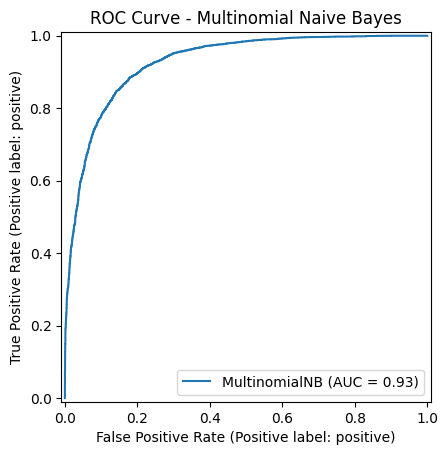

In [70]:
from sklearn.metrics import RocCurveDisplay
# evaluate the model
best_nb = grid_nb.best_estimator_

# predictions
y_pred_nb = best_nb.predict(X_test_tfidf)

# Prediction probabilities (required for ROC-AUC)
y_prob_nb = best_nb.predict_proba(X_test_tfidf)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test.map({'negative':0,'positive':1}), y_prob_nb))

# Plot ROC Curve
RocCurveDisplay.from_estimator(best_nb, X_test_tfidf, y_test)
plt.title("ROC Curve - Multinomial Naive Bayes")
plt.show()

Accuracy : 0.7323787435716447

Classification Report:
               precision    recall  f1-score   support

    negative       0.79      0.63      0.70      4940
    positive       0.69      0.84      0.76      4977

    accuracy                           0.73      9917
   macro avg       0.74      0.73      0.73      9917
weighted avg       0.74      0.73      0.73      9917

Confusion Matrix:
 [[3100 1840]
 [ 814 4163]]
ROC-AUC: 0.765981388882788


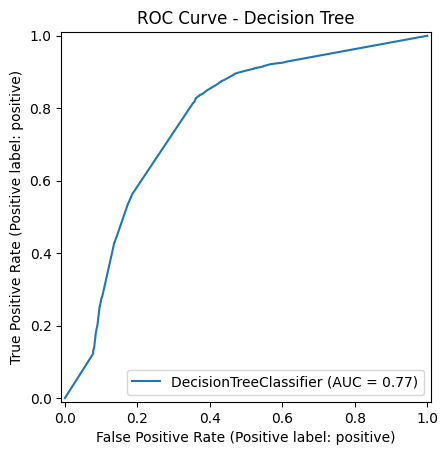

In [71]:
# evaluate the model
best_dt = grid_dt.best_estimator_

# predictions
y_pred_dt = best_dt.predict(X_test_tfidf)

# Prediction probabilities (required for ROC-AUC)
y_prob_dt = best_dt.predict_proba(X_test_tfidf)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test.map({'negative':0,'positive':1}), y_prob_dt))

# Plot ROC Curve
RocCurveDisplay.from_estimator(best_dt, X_test_tfidf, y_test)
plt.title("ROC Curve - Decision Tree")
plt.show()

Accuracy : 0.7472017747302612

Classification Report:
               precision    recall  f1-score   support

    negative       0.79      0.68      0.73      4940
    positive       0.72      0.82      0.76      4977

    accuracy                           0.75      9917
   macro avg       0.75      0.75      0.75      9917
weighted avg       0.75      0.75      0.75      9917

Confusion Matrix:
 [[3336 1604]
 [ 903 4074]]
ROC-AUC: 0.8235602191131838


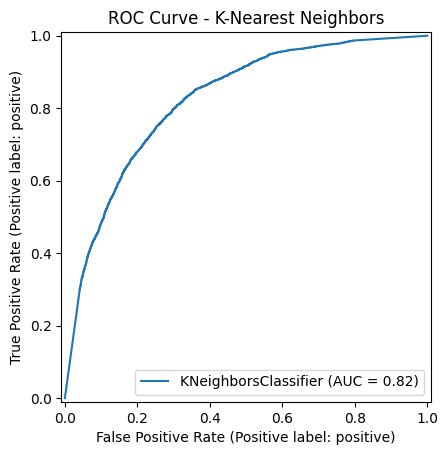

In [72]:
# evaluate the model
best_knn = grid_knn.best_estimator_

# predictions
y_pred_knn = best_knn.predict(X_test_tfidf)

# Prediction probabilities (required for ROC-AUC)
y_prob_knn = best_knn.predict_proba(X_test_tfidf)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test.map({'negative':0,'positive':1}), y_prob_knn))

# Plot ROC Curve
RocCurveDisplay.from_estimator(best_knn, X_test_tfidf, y_test)
plt.title("ROC Curve - K-Nearest Neighbors")
plt.show()

**Compare All Models**

In [73]:
models = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Decision Tree",
        "K-Nearest Neighbors"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ],

    "Precision": [
        precision_score(y_test, y_pred_nb, pos_label="positive"),
        precision_score(y_test, y_pred_dt, pos_label="positive"),
        precision_score(y_test, y_pred_knn, pos_label="positive")
    ],

    "Recall": [
        recall_score(y_test, y_pred_nb, pos_label="positive"),
        recall_score(y_test, y_pred_dt, pos_label="positive"),
        recall_score(y_test, y_pred_knn, pos_label="positive")
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_nb, pos_label="positive"),
        f1_score(y_test, y_pred_dt, pos_label="positive"),
        f1_score(y_test, y_pred_knn, pos_label="positive")
    ],

    "ROC-AUC": [
        roc_auc_score(y_test.map({'negative':0, 'positive':1}), y_prob_nb),
        roc_auc_score(y_test.map({'negative':0, 'positive':1}), y_prob_dt),
        roc_auc_score(y_test.map({'negative':0, 'positive':1}), y_prob_knn)
    ]
})

results = models.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print(results)

                     Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Multinomial Naive Bayes  0.851971   0.849711  0.856540  0.853112  0.927818
1      K-Nearest Neighbors  0.747202   0.717506  0.818565  0.764711  0.823560
2            Decision Tree  0.732379   0.693487  0.836448  0.758288  0.765981


In [74]:
# select the best performance of the model

best_model = results.iloc[0]

print("Best Performance Model")
print("Model:", best_model['Model'])
print("Accuracy:", round(best_model['Accuracy'],4))
print("Precision:", round(best_model['Precision'],4))
print("Recall:", round(best_model['Recall'],4))
print("F1-Score:", round(best_model['F1-Score'],4))
print("ROC-AUC:", round(best_model['ROC-AUC'],4))

Best Performance Model
Model: Multinomial Naive Bayes
Accuracy: 0.852
Precision: 0.8497
Recall: 0.8565
F1-Score: 0.8531
ROC-AUC: 0.9278


**Multinomial Naive Bayes** was selected as the best performing model because it achieved the highest overall performance, with a strong balance between precision and recall and an excellent ROC-AUC score.

# **Model Saving**

In [75]:
import joblib

# Save model
joblib.dump(best_nb, "movie_sentiment_model.pkl")

# Save vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


# **Model Loading**

In [76]:
# Load trained model
model = joblib.load("movie_sentiment_model.pkl")

# Load TF-IDF vectorizer
tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Model and vectorizer loaded successfully!")

Model and vectorizer loaded successfully!


# **Final Conclusion**

**Problem Statement**


The increasing number of movie reviews available online makes it difficult and
time-consuming to manually analyze audience opinions. This project aims to develop a **Movie Sentiment Analysis system** that automatically analyzes movie reviews and classifies them as **positive or negative** using Natural Language Processing (NLP) and Machine Learning techniques.


#**Dataset Summary**

- Number of Records:50000
- Number of Features: 2(review, Sentiment)
- Text Column: text
- Target Variable: labels(Positive / Negative)


#**Best Performing Model**

**Algorithm Selected**

- Multinomial Naive Bayes

**Performance metrics**

- Accuracy: 85.20%
- Precision: 84.97%
- Recall: 85.65%
- F1-Score: 85.31%
- ROC-AUC: 92.78%

# **Key Insights**

**Most Influential Words/Features**

- Sentiment-related words such as good, great, love, best, like, bad, worst, and boring play an important role in distinguishing positive and negative reviews.
- TF-IDF effectively identifies important words by giving higher weight to meaningful terms and reducing the impact of commonly occurring words.

**Business Recommendations**

- Movie platforms can use sentiment analysis to automatically monitor audience feedback and understand viewer satisfaction.
- Negative reviews can help identify common issues related to storytelling, acting, direction, or overall audience experience.

**Practical Applications**

- Movie recommendation systems to improve personalized suggestions.
- Audience feedback analysis for production companies and streaming platforms.
- Review monitoring to track public opinion about movies.
- Content analysis to summarize large volumes of audience reviews.

# **Feature Scope**

- More Data Collection: Use larger and more diverse movie review datasets to improve the model's accuracy and ability to handle different writing styles.
- Advanced preprocessing: Explore
techniques such as handling negations and spelling correction, could further improve text quality.
- Word embeddings: like Word2Vec and GloVe can be explored to better capture the meaning and relationships between words.
- Transformer models: Use advanced models such as BERT and RoBERTa could provide deeper contextual understanding and improve sentiment prediction.
- Deep learning models: like LSTM and GRU can be used to capture patterns and context within longer reviews.
- Ensemble methods could also be explored by combining multiple models to achieve more robust and reliable predictions.